# 20 – Feature Selection

This notebook performs systematic feature selection on the encoded/scaled datasets produced earlier. We use filter (variance, correlation) and wrapper (RFE) methods, selecting features based on validation performance while avoiding leakage.

- Inputs: `12_x_train.csv`, `12_y_train.csv`, `12_x_val.csv`, `12_y_val.csv`, `12_x_test.csv`.
- Outputs: `20_x_train.csv`, `20_y_train.csv`, `20_x_val.csv`, `20_y_val.csv`, `20_x_test.csv`.

Note: All selection and model fitting decisions are made using the training split; validation guides selection; the test set remains untouched until final export.


Important Note: We are doing the feature selection and model tuning on the same validation split. This can inflate our validation results, which we noticed in this submission. We will consider this for the second deliverable. 

## Notebook Overview

Apply filter methods (variance threshold, correlations) followed by wrapper methods (RFE) to select a compact, informative subset of features. Finally, export the feature-selected splits for modeling.


# Table of Contents

<a id="top"></a>

1. [Import Libraries](#sec-1-imports) <br>
2. [Load Dataset](#sec-2-load) <br>
3. [Sanity Checks and Feature Lists](#sec-3-sanity) <br>
4. [Filter Methods](#sec-4-filter) <br>
   &emsp; 4.1 [Variance Threshold (Constant/Quasi-constant)](#sec-4-1-variance) <br>
   &emsp; 4.2 [Correlation Analysis (Pearson, Spearman, Kendall)](#sec-4-2-correlation) <br>
5. [Wrapper Methods](#sec-5-wrapper) <br>
   &emsp; 5.1 [Recursive Feature Elimination (RFE)](#sec-5-1-rfe) <br>
6. [Export Selected Data](#sec-6-export) <br>
7. [Next Steps](#sec-7-next) <br>



<a id="sec-1-imports"></a>
## 1. Import Libraries


Load the encoded splits produced in notebook 12 and confirm shapes before proceeding. <br>
Ensure there are no missing values in any split before running filter/wrapper methods. <br>
Identify numeric vs. categorical features (by naming convention) to scope methods that require numeric inputs.

In [52]:
#Imports
import os
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.base import clone
from datetime import datetime



<a id="sec-2-load"></a>
## 2. Load Dataset


In [ ]:
# Define paths
data_dir = "../data/"
encoded_dir = os.path.join(data_dir, "encoded_data")

# Load automatically the latest folder based on date pattern
latest_folder = sorted(os.listdir(os.path.join(data_dir, "encoded_data")))[-1]

# Load encoded & scaled datasets
x_train = pd.read_csv(os.path.join(encoded_dir, f"{latest_folder}/12_X_train.csv"))
y_train = pd.read_csv(os.path.join(encoded_dir, f"{latest_folder}/12_y_train.csv")).squeeze()

x_val = pd.read_csv(os.path.join(encoded_dir, f"{latest_folder}/12_X_val.csv"))
y_val = pd.read_csv(os.path.join(encoded_dir, f"{latest_folder}/12_y_val.csv")).squeeze()
x_test = pd.read_csv(os.path.join(encoded_dir, f"{latest_folder}/12_X_test.csv"))

# Sanity checks
print("Encoded datasets successfully loaded!")
print(f"x_train shape: {x_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"x_val shape:   {x_val.shape}")
print(f"y_val shape:   {y_val.shape}")
print(f"x_test shape:  {x_test.shape}")


Encoded datasets successfully loaded!
x_train shape: (159975, 241)
y_train shape: (159975, 2)
x_val shape:   (11171, 241)
y_val shape:   (11171, 2)
x_test shape:  (32567, 241)


In [40]:
# Set carID as index
x_train.set_index('carID', inplace=True)
x_val.set_index('carID', inplace=True)
x_test.set_index('carID', inplace=True)
y_train.index = x_train.index
y_val.index = x_val.index

<a id="sec-3-sanity"></a>
## 3. Sanity Checks and Feature Lists


In [41]:
# Missing values
def has_missing(name, x):
    """Return and print total NaNs in a frame.
    Simple sanity check to ensure no missingness before selection.
    """
    n = int(x.isna().sum().sum())
    print(f"[{name}] total NaNs: {n}")
    return n

_ = has_missing("x_train", x_train)
_ = has_missing("x_val",   x_val)
_ = has_missing("x_test",  x_test)


[x_train] total NaNs: 0
[x_val] total NaNs: 0
[x_test] total NaNs: 0


In [42]:
# Show feature names and the types

def show_feature_types(x):
    """Infer feature types by suffix-based convention.
    Any column ending with `_cat` is treated as categorical; others as numerical.
    """
    feature_types = {}
    for col in x.columns:
        if re.search(r'_cat$', col):
            feature_types[col] = 'categorical'
        else:
            feature_types[col] = 'numerical'
    return feature_types

feature_types = show_feature_types(x_train)
num_features = [f for f, t in feature_types.items() if t == 'numerical']
cat_features = [f for f, t in feature_types.items() if t == 'categorical']
print(f"Numerical features ({len(num_features)}): {num_features}")
print(f"Categorical features ({len(cat_features)}): {cat_features}")

Numerical features (240): ['Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Electric', 'fuelType_Hybrid', 'fuelType_Other', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Other', 'transmission_Semi-Auto', 'model_1 Series', 'model_2 Series', 'model_3 Series', 'model_4 Series', 'model_5 Series', 'model_6 Series', 'model_7 Series', 'model_8 Series', 'model_A-Class', 'model_A1', 'model_A2', 'model_A3', 'model_A4', 'model_A5', 'model_A6', 'model_A7', 'model_A8', 'model_Adam', 'model_Agila', 'model_Amarok', 'model_Ampera', 'model_Antara', 'model_Arteon', 'model_Astra', 'model_Auris', 'model_Avensis', 'model_Aygo', 'model_B-Class', 'model_B-MAX', 'model_Beetle', 'model_C-Class', 'model_C-HR', 'model_C-MAX', 'model_CC', 'model_CH-R', 'model_CL-Class', 'model_CLA-Class', 'model_CLC-Class', 'model_CLK-Class', 'model_CLS-Class', 'model_Ca

If any non-numeric columns persist from prior steps, drop them to keep downstream calculations consistent.

In [43]:
# Print datatypes which are not float64 or int64
print("\nFeature datatypes:")
for col in x_train.columns:
    if x_train[col].dtype not in [np.float64, np.int64]:
        print(f" - {col}: {x_train[col].dtype}")


# Drop these columns with incorrect dtypes
cols_to_drop = [col for col in x_train.columns if x_train[col].dtype not in [np.float64, np.int64]]
if cols_to_drop:
    print(f"\nDropping columns with incorrect dtypes: {cols_to_drop}")
    x_train = x_train.drop(columns=cols_to_drop)
    x_val = x_val.drop(columns=cols_to_drop)
    x_test = x_test.drop(columns=cols_to_drop)


Feature datatypes:


<a id="sec-4-filter"></a>
## 4. Filter Methods


We start with Filter methods, because they are computationally inexpensive and helpful for an initial screening of features. 

<a id="sec-4-1-variance"></a>
### 4.1 Variance Threshold (Constant or Quasi-constant)


1. **Setting a Variance Threshold** - useful to deal with features that are constant or quasi-constant - thus, unlikely to be **relevant**


In [44]:
# compute population variance, round for readability, sort by variance desc

x_train.var(ddof=0).round(6).sort_values(ascending=False)


mileage             4.928757e+08
mileage_per_year    1.253068e+08
mpg_x_tax           1.000296e+07
tax_x_age           3.369341e+05
tax_per_age         8.609145e+04
                        ...     
model_CLC-Class     1.900000e-05
model_A2            6.000000e-06
model_Ampera        6.000000e-06
model_Terracan      6.000000e-06
model_S5            6.000000e-06
Length: 240, dtype: float64

We can see that some Features have a very low variance. We will set a threshold of 0.01 to remove features with variance below this value.

In [45]:
# Function to drop low-variance features (below a given threshold)
def drop_low_variance_features(x, threshold=0.01):
    """Remove columns whose variance is below `threshold`.
    Returns the reduced frame and the list of dropped features for consistency across splits.
    """
    # Calculate the variance of each feature
    variances = x.var()
    # Identify features with variance below the threshold
    low_variance_features = variances[variances < threshold].index
    # Drop low-variance features
    x = x.drop(columns=low_variance_features)
    return x, low_variance_features

x_train, dropped_features = drop_low_variance_features(x_train, threshold=0.01)
x_val = x_val.drop(columns=dropped_features)
x_test = x_test.drop(columns=dropped_features)

print(f"Dropped low-variance features: {list(dropped_features)}")

Dropped low-variance features: ['fuelType_Electric', 'fuelType_Other', 'transmission_Other', 'model_1 Series', 'model_2 Series', 'model_8 Series', 'model_A-Class', 'model_A1', 'model_A2', 'model_A3', 'model_A4', 'model_A5', 'model_A7', 'model_Adam', 'model_Agila', 'model_Amarok', 'model_Ampera', 'model_Antara', 'model_Arteon', 'model_Auris', 'model_Avensis', 'model_B-MAX', 'model_Beetle', 'model_C-HR', 'model_CC', 'model_CH-R', 'model_CLA-Class', 'model_CLC-Class', 'model_CLK-Class', 'model_CLS-Class', 'model_Caddy', 'model_Caddy Life', 'model_Caddy Maxi', 'model_Caddy Maxi Life', 'model_California', 'model_Camry', 'model_Caravelle', 'model_Citigo', 'model_Combo Life', 'model_Corolla', 'model_Crossland X', 'model_EcoSport', 'model_Edge', 'model_Eos', 'model_Fabia', 'model_Fusion', 'model_G-Class', 'model_GL-Class', 'model_GLA-Class', 'model_GLB-Class', 'model_GLC-Class', 'model_GLE-Class', 'model_GLS-Class', 'model_GT86', 'model_GTC', 'model_Galaxy', 'model_Getz', 'model_Golf SV', 'mod

In [46]:
# Show all columns after dropping low-variance features
print(f"Remaining features after dropping low-variance features ({x_train.shape[1]}): {list(x_train.columns)}")

Remaining features after dropping low-variance features (82): ['Brand_Audi', 'Brand_BMW', 'Brand_Ford', 'Brand_Hyundai', 'Brand_Mercedes-Benz', 'Brand_Opel', 'Brand_Toyota', 'Brand_Volkswagen', 'Brand_Škoda', 'fuelType_Diesel', 'fuelType_Hybrid', 'fuelType_Petrol', 'transmission_Automatic', 'transmission_Manual', 'transmission_Semi-Auto', 'model_3 Series', 'model_4 Series', 'model_5 Series', 'model_6 Series', 'model_7 Series', 'model_A6', 'model_A8', 'model_Astra', 'model_Aygo', 'model_B-Class', 'model_C-Class', 'model_C-MAX', 'model_CL-Class', 'model_Corsa', 'model_E-Class', 'model_Fiesta', 'model_Focus', 'model_Golf', 'model_Polo', 'model_S-Class', 'model_SL-Class', 'model_TT', 'model_Up', 'model_Yaris', 'model_Zafira', 'model_i10', 'brand_segment_Low', 'brand_segment_Medium', 'brand_segment_Premium', 'car_segment_A - Mini Car', 'car_segment_B - Small Car', 'car_segment_C - Compact Car', 'car_segment_D - Large Family Car', 'car_segment_E - Executive Car', 'car_segment_F - Luxury Car'

<a id="sec-4-2-correlation"></a>
### 4.2 Correlation Analysis (Pearson, Spearman, Kendall Tau)


We have to analyze the Correlation of the features to find things about the relevance and redundancy of the features


1. Select **relevant** features - Correlation with the target (the higher the correlation in absolute value, the more relevant the feature seems to be) 
2. Exclude **redundant** features - Correlation between features (the higher the correlation in absolute value, the more redundant the feature)

For that we will use pearson for linear correlation, spearman and kendall tau for monotonic but non linear relationships and summarize our findings. We dont use Cramers V because we have numeric features.

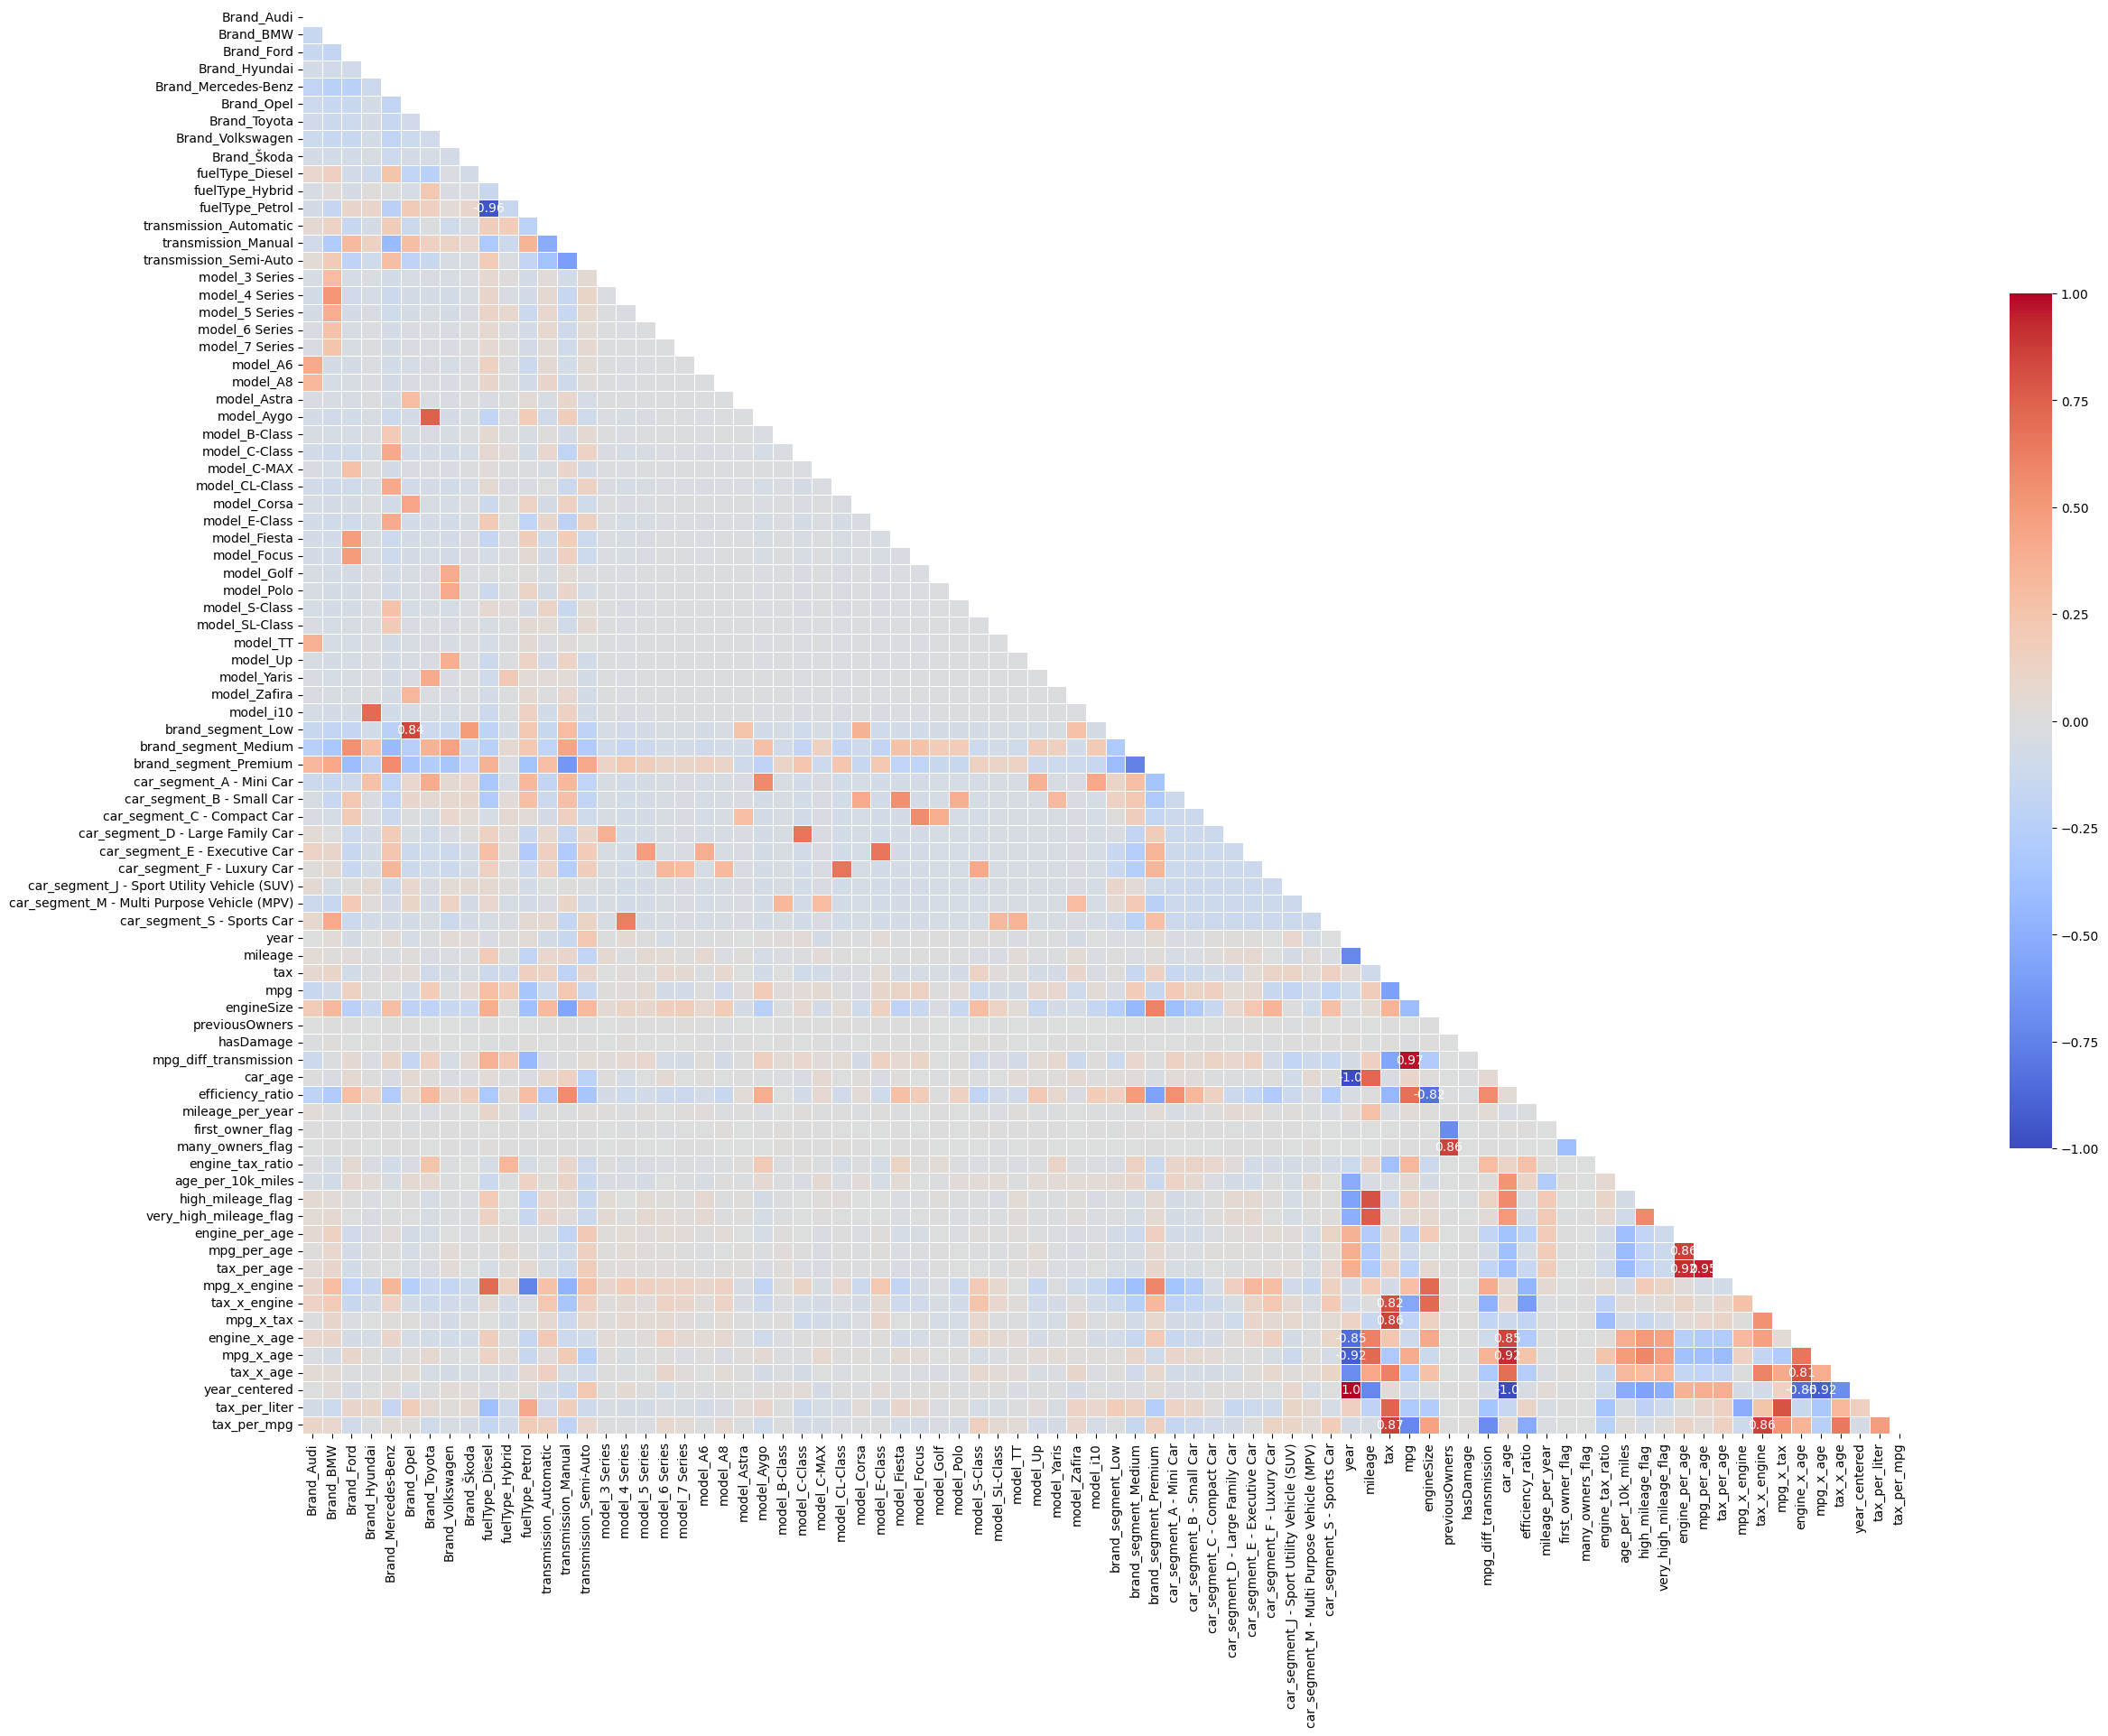

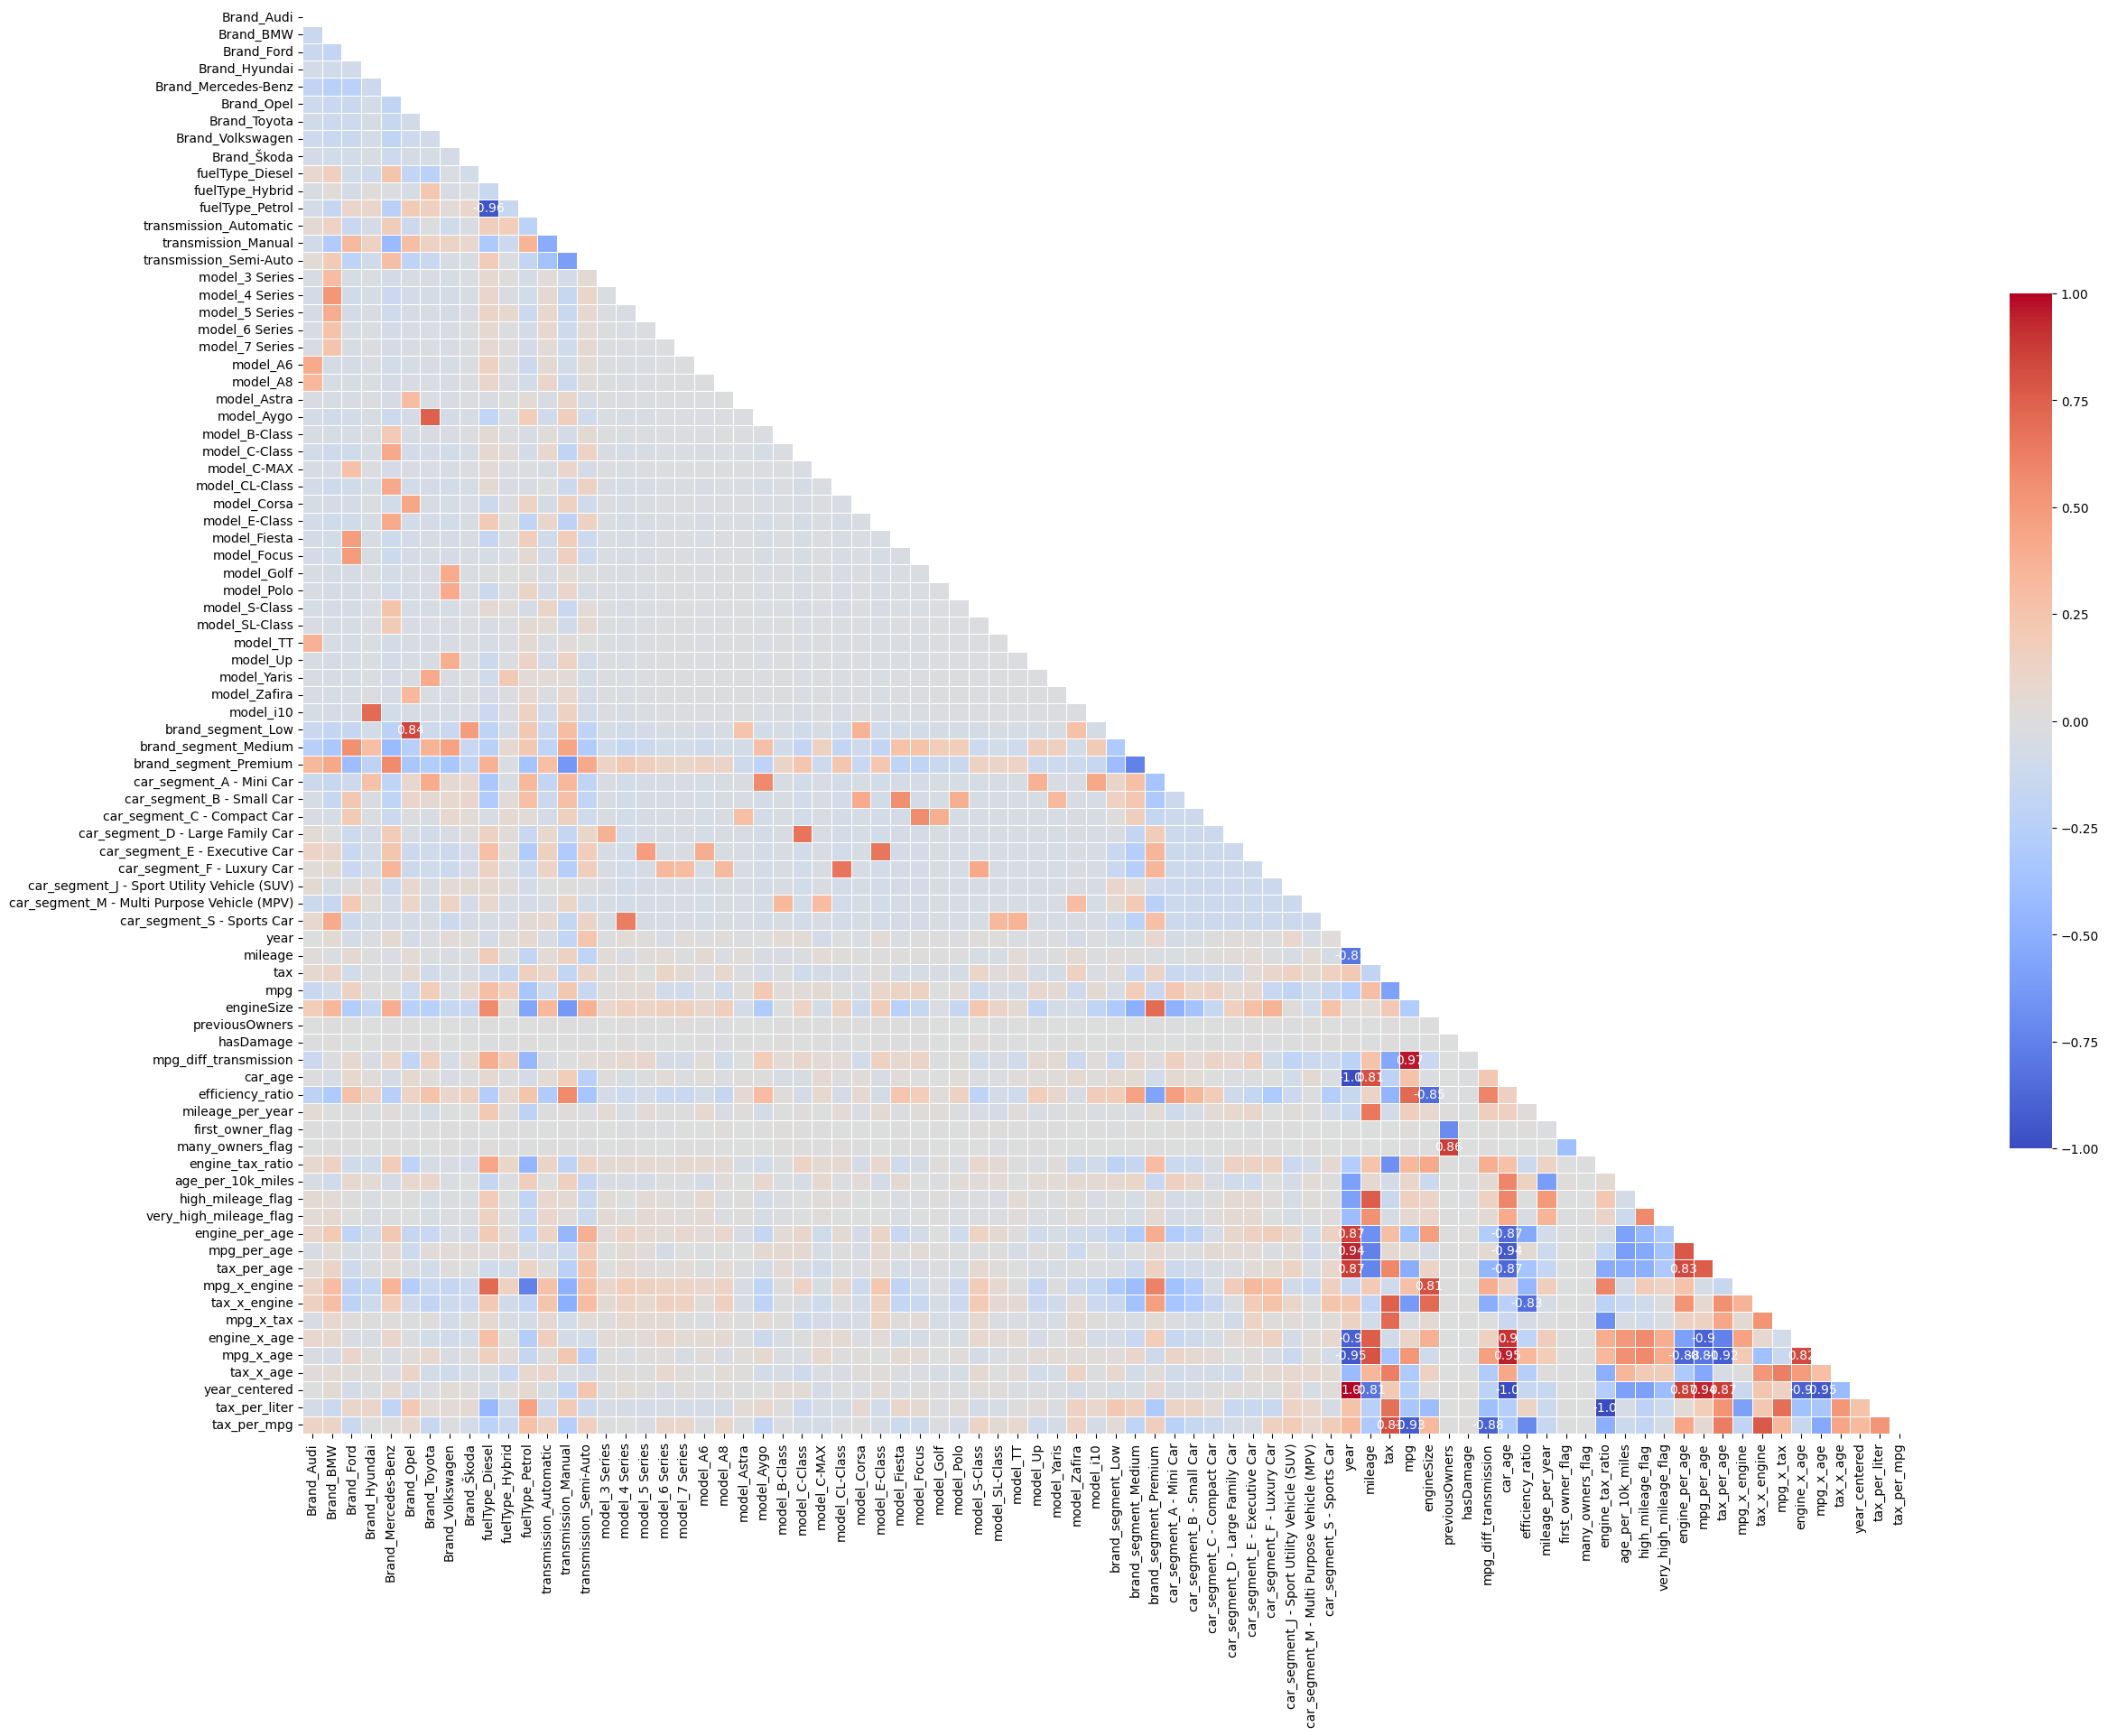

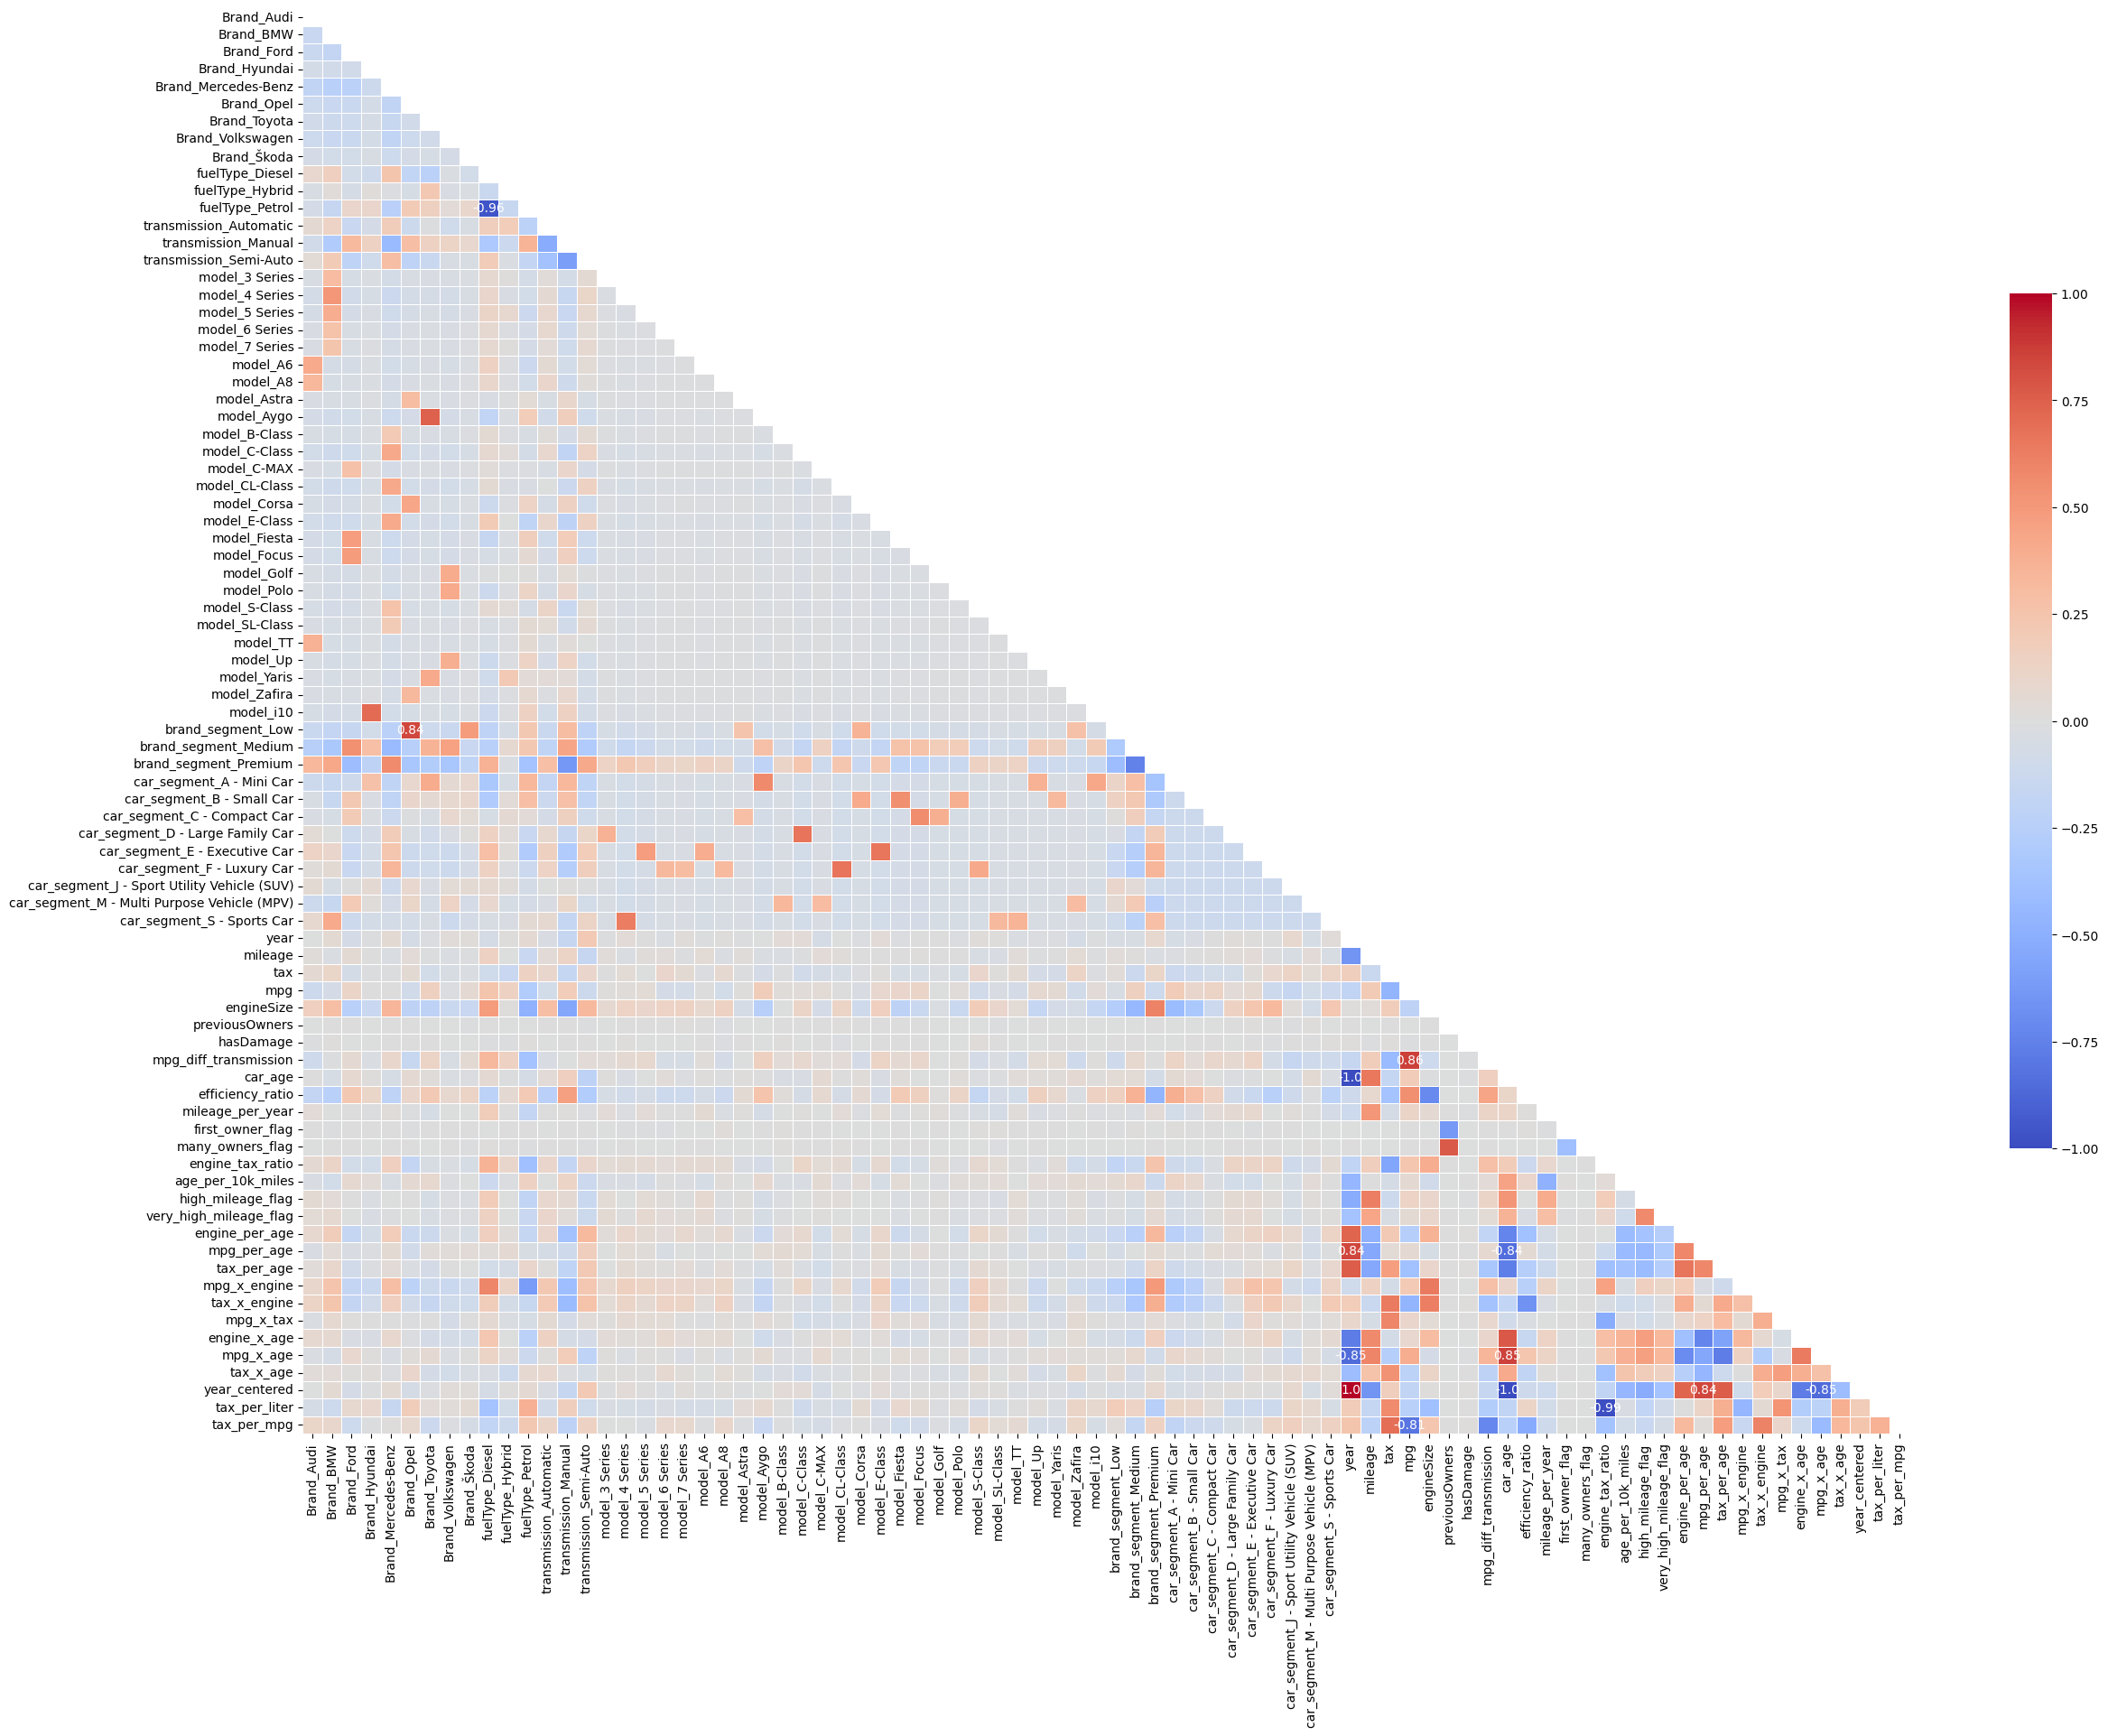

In [47]:
# Pearson, Spearman and Kendall Tau Correlation 
# Visualize feature-feature correlations (target excluded):
# - Pearson: linear relationships
# - Spearman/Kendall: monotonic relationships (rank-based)

methods = ["pearson", "spearman", "kendall"]
threshold = 0.8  # only show annotation when abs(corr) >= threshold

for method in methods:
    cor = x_train.corr(method=method)
    # boolean mask for the upper triangle
    mask = np.triu(np.ones_like(cor, dtype=bool))

    # Create annotation matrix: show numbers only where abs(cor) >= threshold, else empty string
    # round to 2 decimals and convert to strings
    annot_strings = cor.round(2).astype(str)
    annot_matrix = np.where(np.abs(cor) >= threshold, annot_strings, "")
    # ensure upper triangle annotations are empty
    annot_matrix = np.where(mask, "", annot_matrix)

    # optional: scale figure by number of features so labels don't overlap
    n = cor.shape[0]
    figsize = (max(10, n*0.35), max(8, n*0.25))

    plt.figure(figsize=figsize)
    sns.heatmap(
        cor,
        annot=annot_matrix,
        fmt="",              # fmt ignored when annot contains strings
        cmap="coolwarm",
        mask=mask,
        vmin=-1, vmax=1,
        linewidths=0.5,
        cbar_kws={"shrink": 0.6}
    )



Summarize key correlations observed (strength, direction) and note any multicollinearity to address.

In [48]:
# If 2 out of 3 methods show high correlation (>0.9), drop one feature from the pair
def drop_highly_correlated_features(x, threshold=0.9):
    """Drop redundant features based on multi-metric correlation voting.
    If at least two of (Pearson, Spearman, Kendall) exceed `threshold`,
    arbitrarily drop the second feature to reduce multicollinearity.
    Returns the reduced frame and the set of dropped names.
    """
    to_drop = set()
    cor_matrices = {
        "pearson": x.corr(method="pearson"),
        "spearman": x.corr(method="spearman"),
        "kendall": x.corr(method="kendall")
    }
    
    for i in range(len(x.columns)):
        for j in range(i + 1, len(x.columns)):
            col1 = x.columns[i]
            col2 = x.columns[j]
            high_corr_count = sum(
                abs(cor_matrices[method].loc[col1, col2]) > threshold 
                for method in cor_matrices
            )
            if high_corr_count >= 2:
                to_drop.add(col2)  # Arbitrarily drop col2
    
    x = x.drop(columns=list(to_drop))
    return x, to_drop



x_train, dropped_corr_features = drop_highly_correlated_features(x_train, threshold=0.9)
x_val = x_val.drop(columns=dropped_corr_features)
x_test = x_test.drop(columns=dropped_corr_features)

# Debugging: Show the dropped correlated features
print(f"Dropped highly correlated features: {list(dropped_corr_features)}")
# Print the number of the remaining features after dropping highly correlated ones
print(f"Number of remaining features: {x_train.shape[1]}")

Dropped highly correlated features: ['mpg_x_age', 'mpg_diff_transmission', 'car_age', 'tax_per_liter', 'year_centered', 'fuelType_Petrol']
Number of remaining features: 76


<a id="sec-5-wrapper"></a>
## 5. Wrapper Methods


There are different types of Wrapper Methods, we will use Recursive Feature Elimination (RFE) in this case.

- Exhaustive Feature, Forward Feature Selection, Backward Feature Elimination: These methods are computationally expensive and not feasible for datasets with a large number of features.
- Recursive Feature Elimination (RFE): We will use this method because it is computationally efficient and can effectively identify the most relevant features by recursively eliminating the least important ones based on model performance.

<a id="sec-5-1-rfe"></a>
### 5.1 Recursive Feature Elimination (RFE)


We use RFE to find out the optimal number of features to select based on model performance (R² score).

In [ ]:
# Wrapper Methods: Recursive Feature Elimination (RFE)
# Using different models for RFE
# Strategy: sweep number of features (nof_list) and compare validation scores.
# Step size scales with dimensionality to keep runtime reasonable.
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    #"Lasso": Lasso(alpha=0.5, max_iter=5000, tol=1e-3),
    }


# Store results here
results = {}

# Run RFE for each model 
nof_list = np.arange(1, len(x_train.columns) + 1)
step = max(1, len(x_train.columns)//10)

for name, base_model in models.items():
    print(f"\n===== {name} =====")
    train_scores, val_scores = [], []
    best_score = -np.inf
    best_n = 0

    for n in nof_list:
        rfe = RFE(estimator=base_model, n_features_to_select=n, step=step)
        x_train_rfe = rfe.fit_transform(x_train, y_train)
        x_val_rfe   = rfe.transform(x_val)
        model = base_model.fit(x_train_rfe, y_train)

        tr = model.score(x_train_rfe, y_train)
        va = model.score(x_val_rfe, y_val)
        train_scores.append(tr)
        val_scores.append(va)

        if va >= best_score:
            best_score = va
            best_n = n

    results[name] = {"train": train_scores, "val": val_scores, "nof": best_n}
    print(f"Best features: {best_n} | Best val score: {best_score:.4f}")


In [ ]:
# Plot all models together 
plt.figure(figsize=(10, 6))

for name, data in results.items():
    plt.plot(nof_list, data["val"], marker='o', label=f'{name} (Val)')
    plt.axvline(x=data["nof"], linestyle=':', label=f'{name} Opt={data["nof"]}')

plt.title("RFE Comparison: Number of Features vs. Score")
plt.xlabel("Number of Features")
plt.ylabel("Score (R²)")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# Display the selected features for Linear Regression with optimal number of features
model = LinearRegression()
nof = results["LinearRegression"]["nof"]

rfe = RFE(estimator=model, n_features_to_select=nof)
X_rfe = rfe.fit_transform(x_train, y_train)
selected_features = x_train.columns[rfe.support_]
print("Selected features:")
for feature in selected_features:
    print(f" - {feature}")

plt.show()

In [ ]:
# Create smaller subsets to speed up RFE sweeps
# (keep index alignment between x and y)
x_train_subset = x_train.sample(n=1000, random_state=42)
y_train_subset = y_train.loc[x_train_subset.index] 
x_val_subset = x_val.sample(n=200, random_state=42)
y_val_subset = y_val.loc[x_val_subset.index]

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
from sklearn.inspection import permutation_importance


# full pipeline:
# 1) sweep number of features with RFE + RandomForest
# 2) pick best feature set based on validation R²
# 3) refit final model on best features
# 4) plot score curves + permutation importance bar chart

def rfe_sweep_and_importance(
    x_train_subset, y_train_subset,
    x_val_subset,   y_val_subset,
    rf_params=None,
    n_repeats_perm=30,
    random_state=42
):
    if rf_params is None:
        rf_params = {
            "n_estimators": 300,
            "random_state": random_state,
            "n_jobs": -1
        }

    nof_list = np.arange(1, len(x_train_subset.columns) + 1)

    high_score = -np.inf
    best_feature_names = None
    best_nof = 0

    train_score_list = []
    val_score_list = []
    time_list = []

    for k in nof_list:
        model = RandomForestRegressor(**rf_params)

        rfe = RFE(estimator=model, n_features_to_select=k)

        begin = time.perf_counter()

        x_train_rfe = rfe.fit_transform(x_train_subset, y_train_subset)
        x_val_rfe   = rfe.transform(x_val_subset)

        model.fit(x_train_rfe, y_train_subset)

        end = time.perf_counter()

        train_score = model.score(x_train_rfe, y_train_subset)
        val_score   = model.score(x_val_rfe, y_val_subset)

        train_score_list.append(train_score)
        val_score_list.append(val_score)
        time_list.append(end - begin)

        if val_score >= high_score:
            high_score = val_score
            best_nof = k
            best_feature_names = x_train_subset.columns[rfe.support_].tolist()

    print(f"Optimum number of features: {best_nof}")
    print(f"Score with {best_nof} features: {high_score:.6f}")
    print("Selected features:")
    for f in best_feature_names:
        print(" -", f)

    # plot train vs val R² over number of features
    plt.figure(figsize=(7,4))
    plt.plot(nof_list, train_score_list, label="train R²")
    plt.plot(nof_list, val_score_list, label="val R²")
    plt.axvline(best_nof, linestyle="--")
    plt.xlabel("number of selected features")
    plt.ylabel("R² score")
    plt.title("RFE sweep (RandomForest)")
    plt.legend()
    plt.tight_layout()
    plt.show()

    # refit final model on best features only
    X_train_sel = x_train_subset[best_feature_names]
    X_val_sel   = x_val_subset[best_feature_names]

    final_model = RandomForestRegressor(
        n_estimators=max(500, rf_params.get("n_estimators", 300)),
        random_state=random_state,
        n_jobs=-1
    )
    final_model.fit(X_train_sel, y_train_subset)

    # permutation importance on validation set
    perm = permutation_importance(
        final_model,
        X_val_sel,
        y_val_subset,
        n_repeats=n_repeats_perm,
        random_state=random_state,
        scoring="r2",
        n_jobs=-1
    )

    imp_mean = pd.Series(perm.importances_mean, index=best_feature_names)
    imp_std  = pd.Series(perm.importances_std,  index=best_feature_names)
    imp_sorted = imp_mean.sort_values(ascending=True)

    # plot importance
    plt.figure(figsize=(8, max(4, len(imp_sorted)*0.3)))
    plt.barh(
        imp_sorted.index,
        imp_sorted.values,
        xerr=imp_std[imp_sorted.index]
    )
    plt.xlabel("importance (drop in R² when shuffled)")
    plt.title("Feature impact after RFE (Permutation Importance)")
    plt.tight_layout()
    plt.show()

    results = {
        "best_n_features": best_nof,
        "best_val_score": high_score,
        "best_features": best_feature_names,
        "train_scores": train_score_list,
        "val_scores": val_score_list,
        "times": time_list,
        "perm_importance_mean": imp_mean.sort_values(ascending=False),
        "perm_importance_std": imp_std.sort_values(ascending=False),
        "final_model": final_model
    }

    return results


# example call:
# results = rfe_sweep_and_importance(
#     x_train_subset, y_train_subset,
#     x_val_subset,   y_val_subset
# )

In [ ]:
# Sweep number of features for RandomForest RFE (subset)
nof_list=np.arange(1,len(x_train_subset.columns)+1)            
high_score=0
best_feature_names = None  
# Variable to store the optimum features
nof=0           
train_score_list =[]
val_score_list = []

for n in range(len(nof_list)):
    model = RandomForestRegressor(random_state=42)

    rfe = RFE(estimator=model, n_features_to_select=nof_list[n])
    x_train_rfe = rfe.fit_transform(x_train_subset, y_train_subset)
    x_val_rfe = rfe.transform(x_val_subset)
    model.fit(x_train_rfe, y_train_subset)

    # storing results on training data
    train_score = model.score(x_train_rfe, y_train_subset)
    train_score_list.append(train_score)
    
    # storing results on validation data
    val_score = model.score(x_val_rfe, y_val_subset)
    val_score_list.append(val_score)
    
    # track best validation score
    if(val_score >= high_score):
        high_score = val_score
        nof = nof_list[n]
        # store current best feature names
        best_feature_names = x_train_subset.columns[rfe.support_].tolist()

print("Optimum number of features: %d" %nof)
print("Score with %d features: %f" % (nof, high_score))
print("Selected features:")
for feature in best_feature_names:
    print(f" - {feature}")


We adopt the feature set from RandomForest RFE on the subset, as it achieved the best validation score among the tested configurations.

In [ ]:
# We select the features (best_feature_names) from random forest results, because it gave the best performance

x_train = x_train[best_feature_names]
x_val = x_val[best_feature_names]
x_test = x_test[best_feature_names]


<a id="sec-6-export"></a>
## 6. Export Selected Data

Export the feature-selected datasets for downstream modeling (notebook 30):
- `20_x_train.csv`, `20_y_train.csv`
- `20_x_val.csv`, `20_y_val.csv`
- `20_x_test.csv`


In [49]:
# Print number of columns of the new datasets (post-selection)
print(f"x_train shape after feature selection: {x_train.shape}")
print(f"x_val shape after feature selection:   {x_val.shape}")
print(f"x_test shape after feature selection:  {x_test.shape}")

x_train shape after feature selection: (159975, 76)
x_val shape after feature selection:   (11171, 76)
x_test shape after feature selection:  (32567, 76)


In [51]:
# Export the dataset with selected features only

# Get current date string
date_str = datetime.now().strftime("%Y%m%d_%H%M")

# Define output directory
output_dir = os.path.join(data_dir, f"feature_selection/{date_str}")
os.makedirs(output_dir, exist_ok=True)

# Save the processed datasets
print(f"Saving feature_selected data to {output_dir}...")

x_train.to_csv(os.path.join(output_dir, "20_x_train.csv"), index=True)
y_train.to_csv(os.path.join(output_dir, "20_y_train.csv"), index=False)
x_val.to_csv(os.path.join(output_dir, "20_x_val.csv"), index=True)
y_val.to_csv(os.path.join(output_dir, "20_y_val.csv"), index=False)
x_test.to_csv(os.path.join(output_dir, "20_x_test.csv"), index=True)

print ("Feature selected data saved successfully (x/y separated):")

Saving feature_selected data to ../data/feature_selection/20251210_1721...
Feature selected data saved successfully (x/y separated):


In [12]:
# Add some Logging info for this feature selection run and save it into a log file in the same output directory
log_file = os.path.join(output_dir, "feature_selection_log.txt")
with open(log_file, "w") as f:
    f.write(f"Feature Selection Log - {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"Optimum number of features: {nof}\n")
    f.write(f"Best validation R² score: {high_score:.6f}\n")
    f.write("Selected features:\n")
    for feature in best_feature_names:
        f.write(f" - {feature}\n")
print(f"Log file saved to {log_file}")


NameError: name 'nof' is not defined

<a id="sec-7-next"></a>
### Next Steps
In the next notebook, we will proceed to modeling and evaluation using the feature-selected datasets prepared here.

[Back to top](#top)
